In [6]:
!pip install pandas openpyxl scipy numpy

In [7]:
from IPython.display import display
import pandas as pd

In [8]:
import pandas as pd
import numpy as np
from scipy import stats

In [11]:
# Load dataset
df = pd.read_excel("Blinkit Excel Data.xlsx")

# Preview
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDY49,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.011954,NaN,164.5184,4
1,Low Fat,NCJ54,Household,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.059776,NaN,231.7642,4
2,Low Fat,FDP11,Breads,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.068766,NaN,216.9166,4
3,Low Fat,FDR23,Breads,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.081391,NaN,177.8370,4
4,Low Fat,FDB27,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.055122,NaN,196.7768,4


In [12]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Fix category formatting
df['outlet_location_type'] = df['outlet_location_type'].str.strip().str.title()

print("Columns:", df.columns.tolist())

Columns: ['item_fat_content', 'item_identifier', 'item_type', 'outlet_establishment_year', 'outlet_identifier', 'outlet_location_type', 'outlet_size', 'outlet_type', 'item_visibility', 'item_weight', 'sales', 'rating']


In [13]:
location_col = 'outlet_location_type'
sales_col = 'sales'

In [14]:
tier1 = df[df[location_col] == 'Tier 1'][sales_col].dropna()
tier3 = df[df[location_col] == 'Tier 3'][sales_col].dropna()

print("Tier 1 count:", len(tier1))
print("Tier 3 count:", len(tier3))

Tier 1 count: 2388
Tier 3 count: 3350


In [15]:
t_stat, p_value = stats.ttest_ind(tier3, tier1, equal_var=False)

print("--- Hypothesis Test ---")
print("T-statistic:", t_stat)
print("P-value:", p_value)

--- Hypothesis Test ---
T-statistic: 0.039044550301590764
P-value: 0.9688563803737086


In [16]:
pooled_std = np.sqrt((tier3.std()**2 + tier1.std()**2) / 2)
effect_size = (tier3.mean() - tier1.mean()) / pooled_std

print("--- Effect Size ---")
print("Cohen's d:", effect_size)

--- Effect Size ---
Cohen's d: 0.0010451688731897358


In [17]:
mean_diff = tier3.mean() - tier1.mean()

se = np.sqrt((tier3.var()/len(tier3)) + (tier1.var()/len(tier1)))
ci_lower = mean_diff - 1.96 * se
ci_upper = mean_diff + 1.96 * se

print("--- Confidence Interval ---")
print("Mean Difference:", mean_diff)
print("95% CI:", (ci_lower, ci_upper))

--- Confidence Interval ---
Mean Difference: 0.06512826340656375
95% CI: (np.float64(-3.2042498006472084), np.float64(3.334506327460336))


In [18]:
print("--- Conclusion ---")

if p_value < 0.05:
    print("Statistically significant difference")
    print("Tier 3 outlets outperform Tier 1 outlets.")
else:
    print("No statistically significant difference")
    print("Difference may be due to random variation.")

--- Conclusion ---
No statistically significant difference
Difference may be due to random variation.


In [20]:
!pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.3 MB 12.1 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 11.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 10.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 8.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.0 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 18.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.6 MB/s  0:00:00
   -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


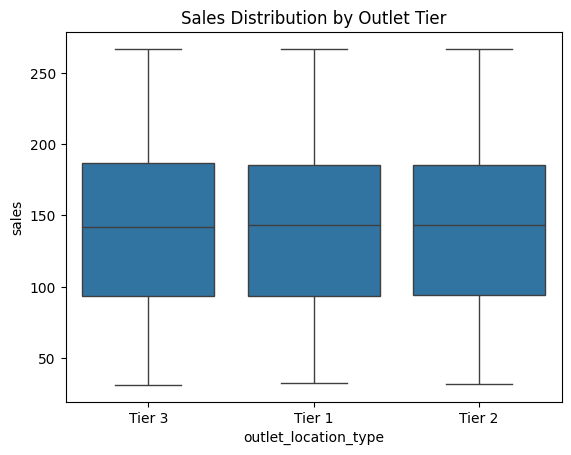

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df[location_col], y=df[sales_col])
plt.title("Sales Distribution by Outlet Tier")
plt.show()